<div align="center">
<p align="center" style="width: 100%;">
    <img src="https://raw.githubusercontent.com/vlm-run/.github/refs/heads/main/profile/assets/vlm-black.svg" alt="VLM Run Logo" width="80" style="margin-bottom: -5px; color: #2e3138; vertical-align: middle; padding-right: 5px;"><br>
</p>
<p align="center"><a href="https://vlm.run"><b>Website</b></a> | <a href="https://docs.vlm.run/"><b>API Docs</b></a> | <a href="https://vlm.run/blog"><b>Blog</b></a> | <a href="https://discord.gg/AMApC2UzVY"><b>Discord</b></a>
</p>
</div>

# Orion-2 Demo: Healthcare Multi-Document Workflow

This notebook runs an end-to-end demo of **VLM Run's Orion-2** on a stack of healthcare documents, using a **single chat completion** to do the whole job:

1. **Download** four source documents and **merge** them into a single PDF
   (one is a JPG, so it's converted to PDF first), and **preview** each input page.
2. **Classify + extract in one completion**: send the combined PDF to Orion-2 and ask it to:
   - split the bundle back into individual documents and label each as an *insurance form* or a *health record form*, and
   - **figure out on its own** which document is the physician referral form, extract every handwritten field, and render bounding-box detections on top.

   Crucially, we **don't tell it which file is the referral**. The merged bundle is the only input, so the model has to identify the handwritten referral form itself. That's the point of the demo.
3. **Render the results**: a classification table, the extracted markdown, and the annotated bbox image, all from that one completion.

**Docs:**
- [Orion-2: Code Execution](https://docs.vlm.run/agents/code-execution)
- [Artifacts](https://docs.vlm.run/agents/artifacts)

---
## 1. Setup

In [1]:
# Install required packages
!pip install "vlmrun[openai]" --upgrade --quiet
!pip install pypdf pymupdf pillow requests pandas --quiet

In [2]:
import os

# In Colab, retrieve the API key from Colab Secrets (key icon in the left sidebar).
try:
    from google.colab import userdata
    VLMRUN_API_KEY = userdata.get("VLMRUN_API_KEY")
except (ImportError, Exception):
    import getpass
    VLMRUN_API_KEY = os.getenv("VLMRUN_API_KEY") or getpass.getpass("Enter your VLM Run API key: ")

print(f"API key loaded: {'yes' if VLMRUN_API_KEY else 'no'}")

API key loaded: yes


In [3]:
from vlmrun.client import VLMRun

BASE_URL = os.getenv("VLMRUN_BASE_URL", "https://agent.vlm.run/v1")
client = VLMRun(api_key=VLMRUN_API_KEY, base_url=BASE_URL)
print(f"VLM Run client initialized (base_url={BASE_URL})")

VLM Run client initialized (base_url=https://agent.vlm.run/v1)


---
## 2. Source documents

Four publicly hosted healthcare documents from the VLM Run cookbook. `form4` is a JPG (patient insurance card) and will be converted to PDF before merging.

These labels are only for our own bookkeeping when we merge; **they are never sent to the model**. Orion-2 only ever sees the single combined PDF and has to work out what each document is on its own.

In [4]:
# Physician referral form (handwritten): PDF
form1 = "https://storage.googleapis.com/vlm-data-public-prod/hub/examples/healthcare.patient-referral/handwritten-patient-referral.pdf"
# Medicare CMS-1500 claim (filled): PDF
form2 = "https://storage.googleapis.com/vlm-data-public-prod/hub/examples/healthcare.medicare-claim/form-cms1500-filled.pdf"
# Patient medical history form: PDF
form3 = "https://storage.googleapis.com/vlm-data-public-prod/hub/examples/healthcare.patient-medical-history/medical-history-form.pdf"
# Patient insurance card: JPG (needs conversion)
form4 = "https://storage.googleapis.com/vlm-data-public-prod/hub/examples/healthcare.patient-insurance-card/12d82480-ad93-49b4-b02a-da0526cca713_0.jpg"

DOCUMENTS = [
    ("form1: physician referral (handwritten)", form1),
    ("form2: CMS-1500 medicare claim",          form2),
    ("form3: patient medical history",           form3),
    ("form4: patient insurance card (jpg)",      form4),
]
print("Documents defined.")

Documents defined.


---
## 3. Helper utilities

In [5]:
import base64
import requests
from io import BytesIO
from pathlib import Path

import pandas as pd
from PIL import Image
from pydantic import BaseModel, Field
from pypdf import PdfReader, PdfWriter
from IPython.display import display, HTML, Markdown

from typing import List, Literal
from vlmrun.types import ImageRef

import re
import fitz  # PyMuPDF: rasterizes PDF pages without poppler/apt

# Healthcare forms contain interactive AcroForm widgets; silence MuPDF's
# non-fatal "cannot create appearance stream for widgets" warnings.
fitz.TOOLS.mupdf_display_errors(False)


def fetch_bytes(url: str) -> bytes:
    """Download raw bytes from a URL."""
    resp = requests.get(url)
    resp.raise_for_status()
    return resp.content


def to_pdf_bytes(url: str) -> bytes:
    """Return the document as PDF bytes, converting images (jpg/png) to PDF on the fly."""
    data = fetch_bytes(url)
    ext = url.lower().split("?")[0]
    if ext.endswith((".jpg", ".jpeg", ".png", ".webp", ".bmp", ".tiff")):
        img = Image.open(BytesIO(data)).convert("RGB")
        buf = BytesIO()
        img.save(buf, format="PDF")
        return buf.getvalue()
    return data  # already a PDF


def show_image(img: Image.Image, caption: str = "", width: int = 600):
    """Display a PIL image inline in the notebook."""
    buf = BytesIO()
    img.convert("RGB").save(buf, format="JPEG")
    b64 = base64.b64encode(buf.getvalue()).decode()
    html = (
        "<div style='display:inline-block; margin:5px; text-align:center'>"
        f"<img src='data:image/jpeg;base64,{b64}' style='max-width:{width}px; border-radius:6px'>"
    )
    if caption:
        html += f"<div style='font-size:12px; color:#666; margin-top:5px'>{caption}</div>"
    html += "</div>"
    display(HTML(html))


def render_pdf_page(pdf_bytes: bytes, page_index: int = 0, zoom: float = 2.0) -> Image.Image:
    """Rasterize a single page of a PDF (given as bytes) to a PIL image."""
    doc = fitz.open(stream=pdf_bytes, filetype="pdf")
    page_index = max(0, min(page_index, doc.page_count - 1))
    # Flatten form fields/annotations into static content so widgets render
    # cleanly instead of throwing appearance-stream errors.
    try:
        doc.bake()  # PyMuPDF >= 1.23 (annots=True, widgets=True by default)
    except Exception:
        pass
    pix = doc.load_page(page_index).get_pixmap(matrix=fitz.Matrix(zoom, zoom))
    img = Image.frombytes("RGB", [pix.width, pix.height], pix.samples)
    doc.close()
    return img


def show_images_grid(items, width: int = 240):
    """Render a list of (PIL image, caption) tuples as a responsive grid."""
    html = "<div style='display:flex; flex-wrap:wrap; gap:14px; align-items:flex-start'>"
    for img, caption in items:
        buf = BytesIO()
        img.convert("RGB").save(buf, format="JPEG", quality=85)
        b64 = base64.b64encode(buf.getvalue()).decode()
        html += (
            f"<div style='text-align:center; width:{width}px'>"
            f"<img src='data:image/jpeg;base64,{b64}' "
            f"style='width:{width}px; border:1px solid #ddd; border-radius:6px'>"
            f"<div style='font-size:12px; color:#555; margin-top:6px'>{caption}</div>"
            "</div>"
        )
    html += "</div>"
    display(HTML(html))


def page_thumb_data_uri(pdf_path: Path, page_index: int = 0, width: int = 130) -> str:
    """Return a base64 <img>-ready data URI for one page of a PDF on disk."""
    img = render_pdf_page(Path(pdf_path).read_bytes(), page_index=page_index, zoom=1.5)
    img.thumbnail((width, width * 2))
    buf = BytesIO()
    img.save(buf, format="JPEG", quality=80)
    b64 = base64.b64encode(buf.getvalue()).decode()
    return f"data:image/jpeg;base64,{b64}"


def first_page_index(pages_str) -> int:
    """Parse the first page number out of a model-provided page range ('2-3' -> index 1)."""
    m = re.search(r"\d+", str(pages_str))
    return (int(m.group()) - 1) if m else 0


print("Helpers loaded.")

Helpers loaded.


---
## 4. Download, convert & concatenate into one PDF

We pull each document, convert the JPG insurance card to PDF, and merge everything into a single `combined_healthcare_docs.pdf` while tracking each source's page count (handy for sanity-checking the model's own page counts later).

In [6]:
writer = PdfWriter()
page_counts = []

for name, url in DOCUMENTS:
    pdf_bytes = to_pdf_bytes(url)
    reader = PdfReader(BytesIO(pdf_bytes))
    n_pages = len(reader.pages)
    for page in reader.pages:
        writer.add_page(page)
    page_counts.append((name, n_pages))
    print(f"  + {name:<45} {n_pages} page(s)")

combined_path = Path("combined_healthcare_docs.pdf")
with open(combined_path, "wb") as f:
    writer.write(f)

total_pages = sum(n for _, n in page_counts)
print(f"\nMerged {len(DOCUMENTS)} documents → {combined_path} ({total_pages} pages total).")

  + form1: physician referral (handwritten)       1 page(s)
  + form2: CMS-1500 medicare claim                2 page(s)
  + form3: patient medical history                1 page(s)
  + form4: patient insurance card (jpg)           1 page(s)

Merged 4 documents → combined_healthcare_docs.pdf (5 pages total).


---
## 5. Preview the input documents

Before classifying anything, render the first page of each source document so it's clear what's going into the model. (The JPG insurance card is converted to PDF first, exactly as it is for the merge.)


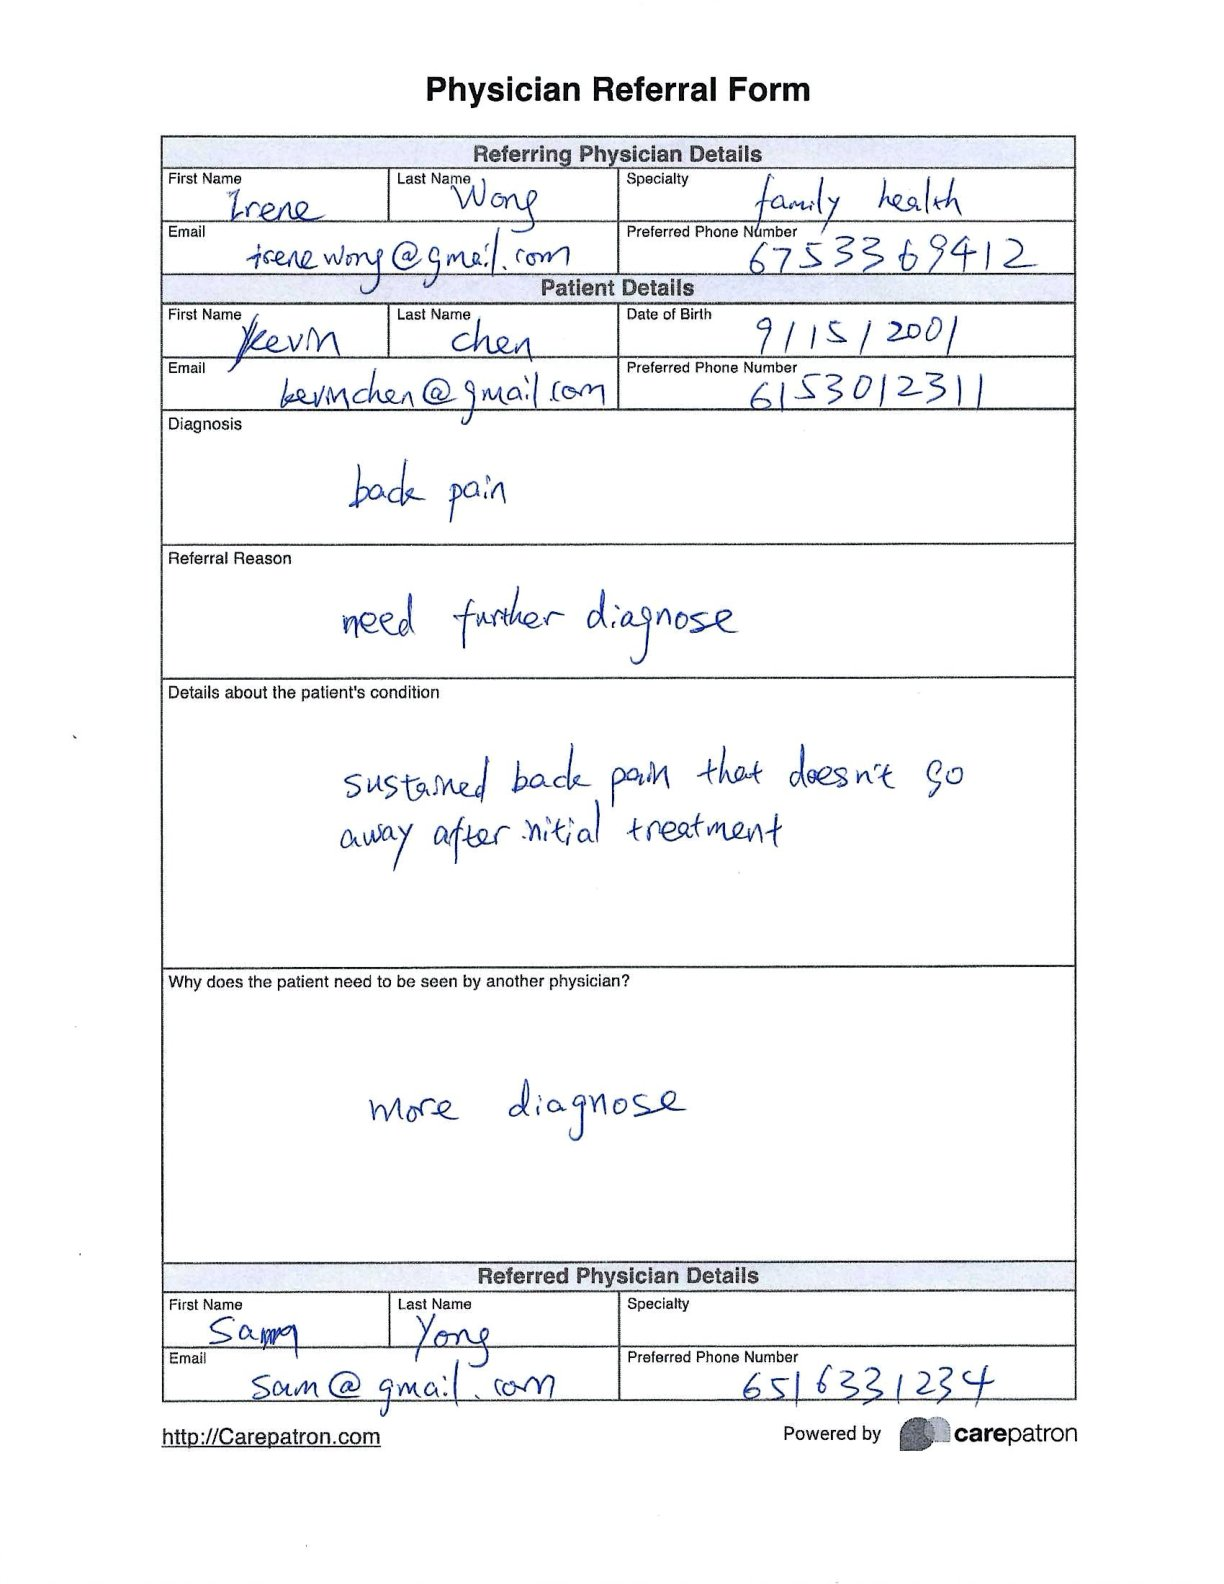
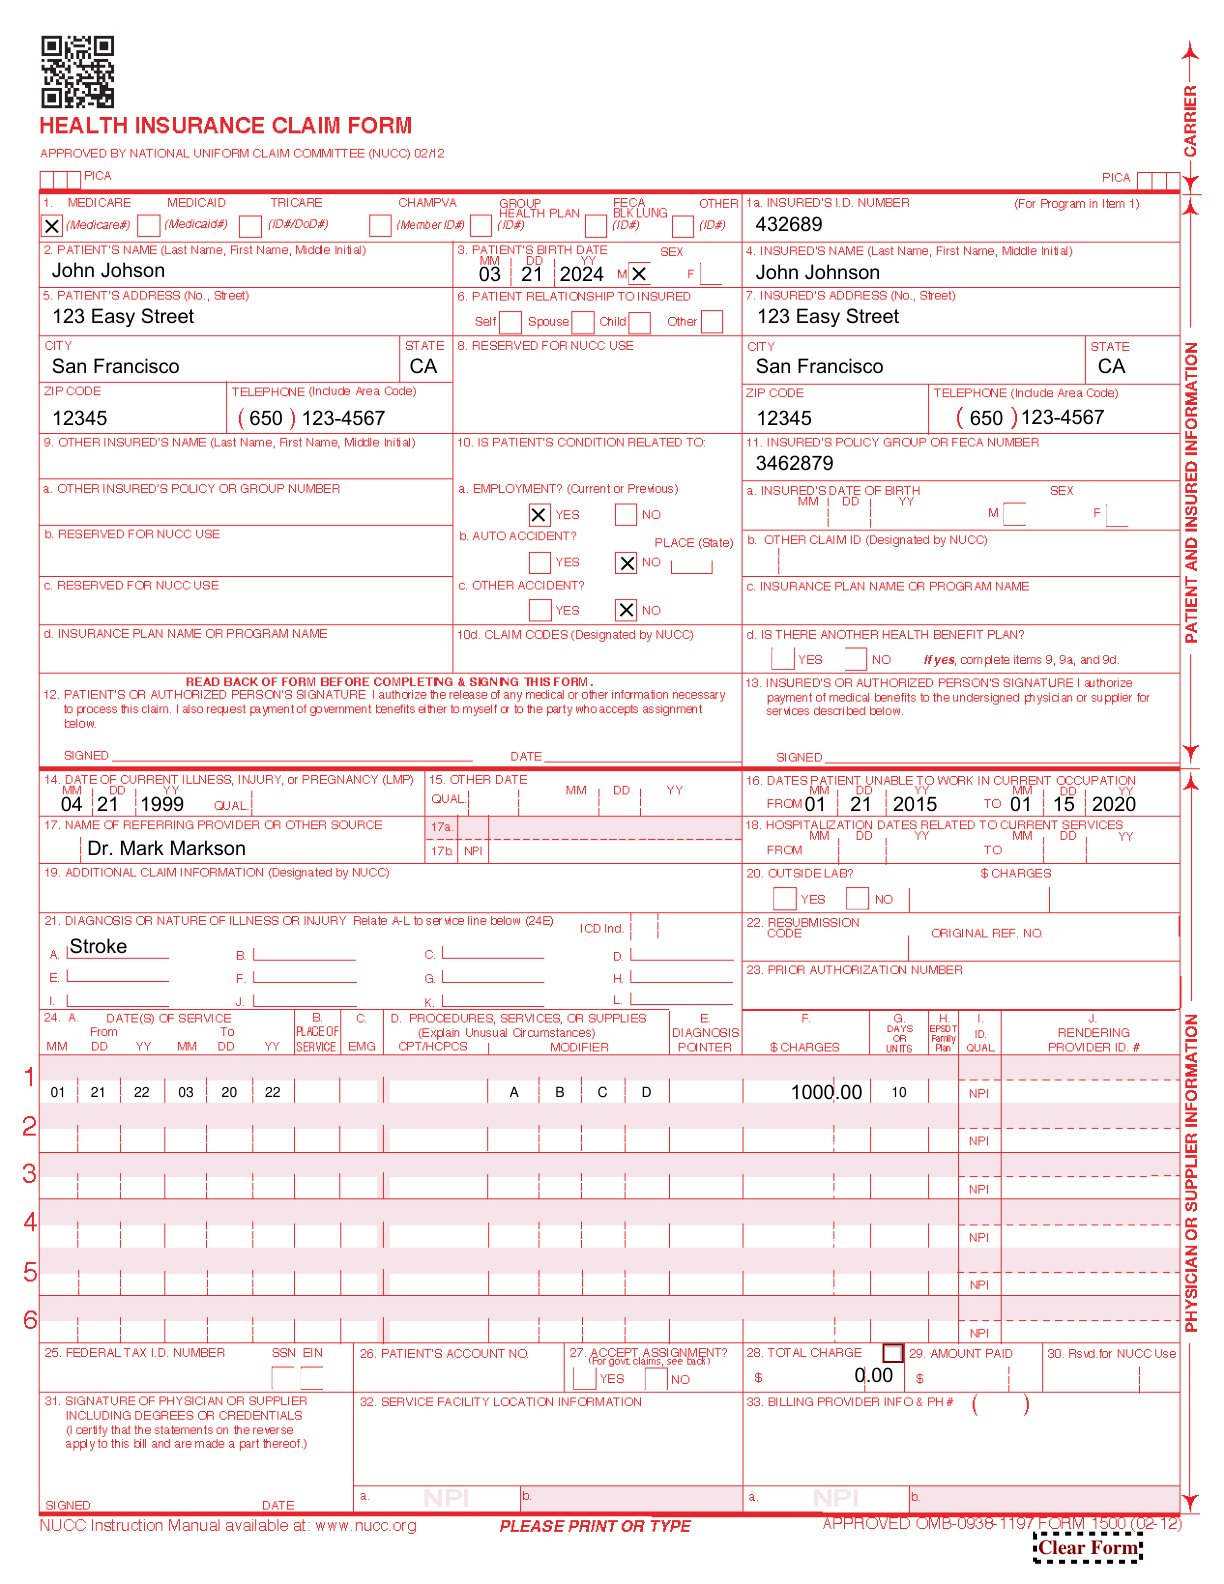
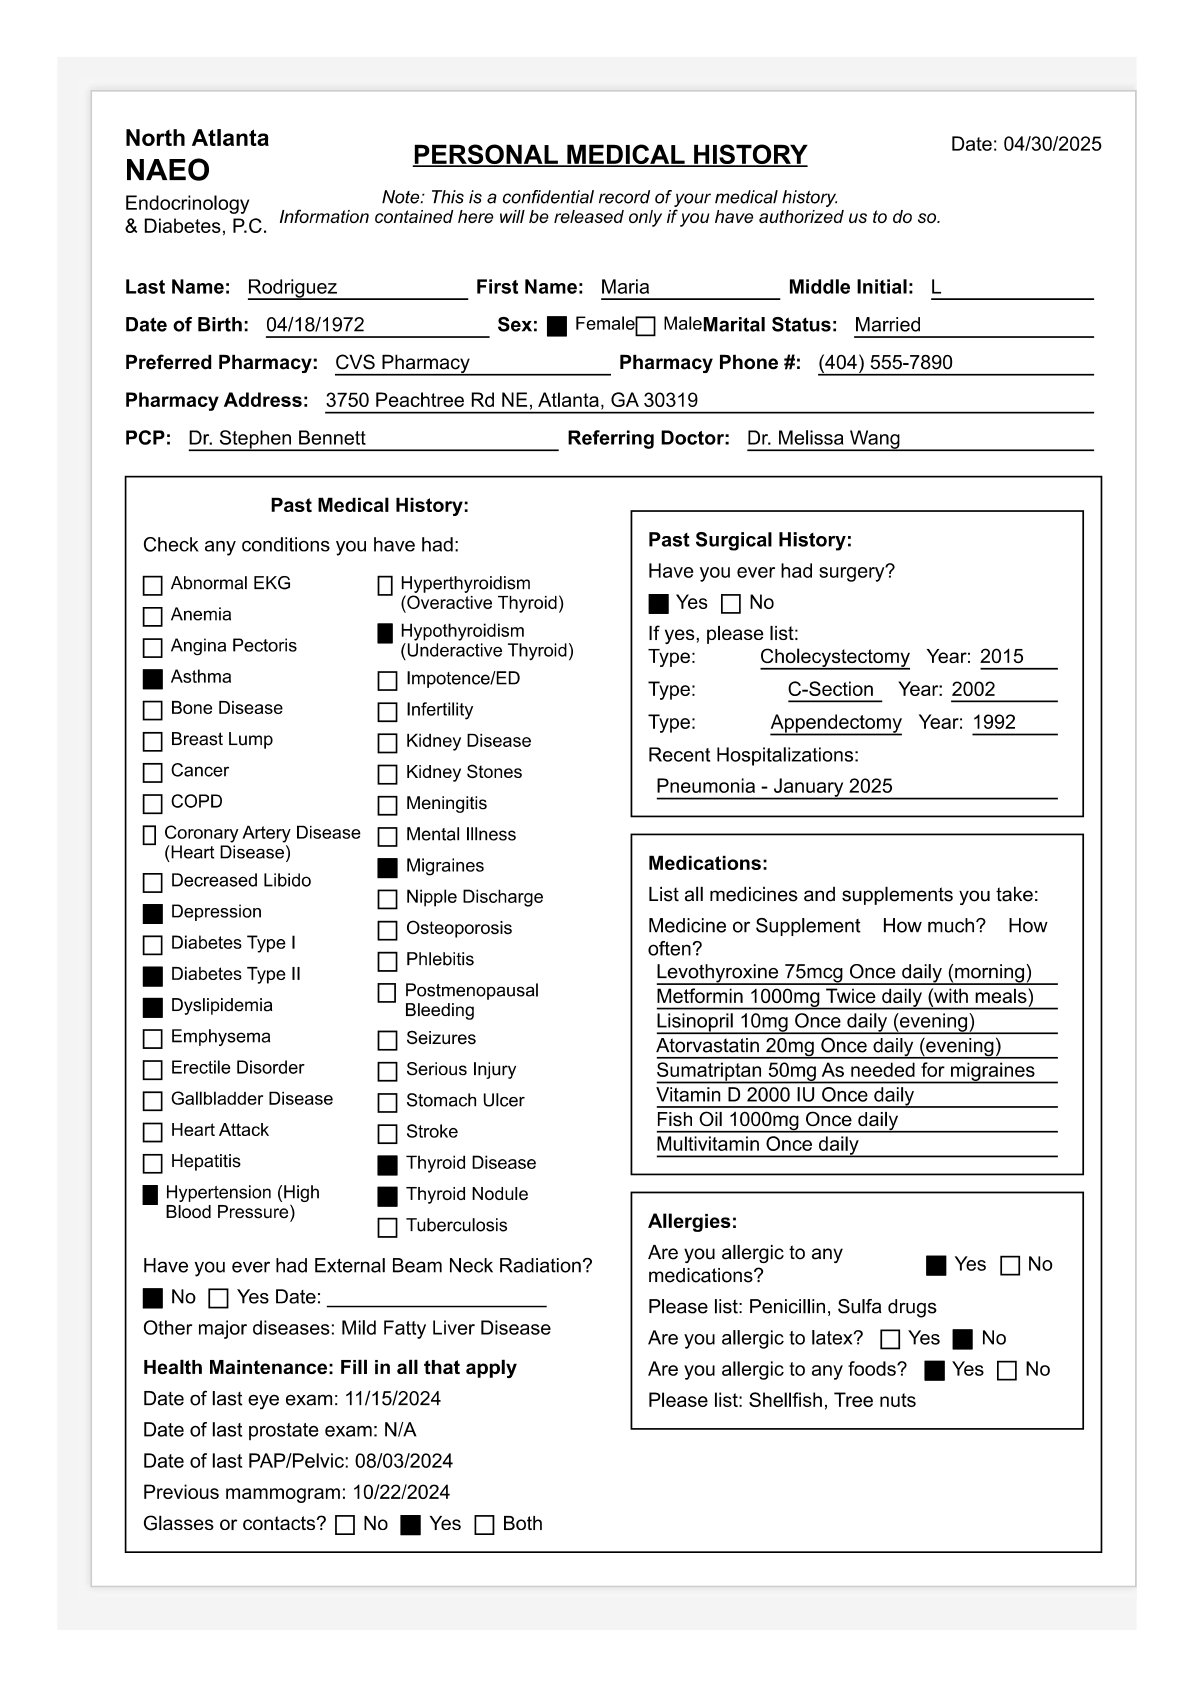
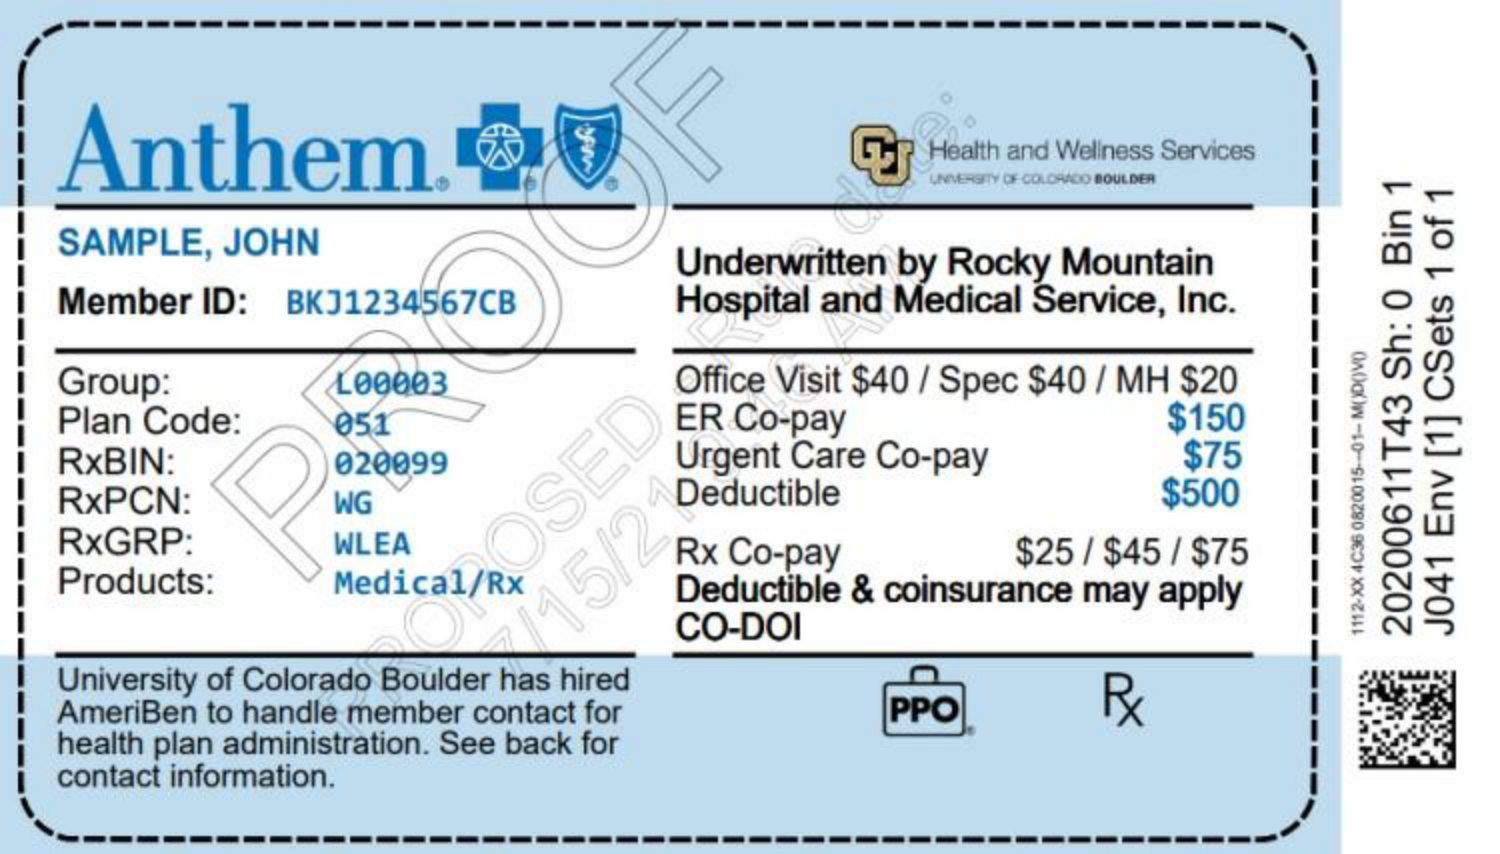

In [7]:
previews = []
for name, url in DOCUMENTS:
    page0 = render_pdf_page(to_pdf_bytes(url), page_index=0)
    previews.append((page0, name))

show_images_grid(previews, width=240)

---
## 6. Classify **and** extract in a single Orion-2 completion

This is the heart of the demo. We make **one** `client.agent.completions.create` call on the merged PDF with a structured `response_format` that captures everything at once:

- `documents`: every document the model splits out of the bundle, with its page range, page count, and class (*insurance form* / *health record form*).
- `referral_document`: the document the model **identifies on its own** as the physician referral form.
- `referral_markdown`: all handwritten fields it extracts from that referral form.
- `annotated_image`: an `ImageRef` to the referral page rendered with bounding-box detections.

Nothing in the prompt names `form1` or tells the model where the referral is; it has to find it from the content of the bundle. That's what makes this an intelligent, not hard-coded, pipeline.

In [8]:
class ClassifiedDocument(BaseModel):
    document: str = Field(..., description="Short descriptive name for the document, e.g. 'Physician referral form'")
    pages: str = Field(..., description="Page range within the combined PDF, e.g. '1' or '2-3'")
    page_count: int = Field(..., description="Number of pages this document spans")
    document_class: Literal["insurance form", "health record form"] = Field(
        ..., description="Whether the document is an insurance form or a health record form"
    )


class HealthcareAnalysis(BaseModel):
    documents: List[ClassifiedDocument] = Field(
        ..., description="Every individual document found in the combined PDF, split apart and classified"
    )
    referral_document: str = Field(
        ..., description="The name of the document identified as the physician referral form"
    )
    referral_markdown: str = Field(
        ..., description="Markdown of all handwritten information extracted from the physician referral form"
    )
    annotated_image: ImageRef = Field(
        ...,
        description=(
            "The physician referral form rendered with bounding-box detections drawn on top of "
            "each extracted handwritten field"
        ),
    )


PROMPT = (
    "This PDF is several separate healthcare documents merged into one file. "
    "1. Split the bundle back into its individual documents. For each one, give a short name, its "
    "page range, its page count, and classify it as either an 'insurance form' or a 'health record form'. "
    "2. Then, on your own, determine which of those documents is the physician referral form (it is the "
    "one filled out by hand). Extract ALL of the handwritten information from it, render bounding-box "
    "detections on top of each extracted field, and return the extracted information as markdown. "
    "Do not assume any fixed document ordering, decide everything from the content itself."
)

# Encode the merged PDF as a base64 data URL and pass it inline via file_url.
pdf_b64 = base64.b64encode(combined_path.read_bytes()).decode()
pdf_data_url = f"data:application/pdf;base64,{pdf_b64}"

response = client.agent.completions.create(
    model="vlmrun-orion-2:pro",
    messages=[
        {
            "role": "user",
            "content": [
                {"type": "text", "text": PROMPT},
                {"type": "file_url", "file_url": {"url": pdf_data_url}},
            ],
        }
    ],
    response_format={
        "type": "json_schema",
        "schema": HealthcareAnalysis.model_json_schema(),
    },
)

session_id = response.session_id
print("Session ID:", session_id)

# Parse the structured response.
try:
    analysis = HealthcareAnalysis.model_validate_json(response.choices[0].message.content)
    print(f"Parsed {len(analysis.documents)} documents | "
          f"referral identified as: {analysis.referral_document!r}")
except Exception as e:
    analysis = None
    print(f"(structured parse failed: {e})\n\nRaw response content:\n")
    print(response.choices[0].message.content)

Session ID: d20242fb-51cf-4783-a2af-3f2fa29147dd
Parsed 4 documents | referral identified as: 'Physician referral form'


In [9]:
def style_table(df, table_width=None, col_widths=None, align="left"):
    """Consistent pandas Styler shared by every output table.
       table_width: e.g. '640px' -> fixed layout so multiple tables align.
       col_widths:  dict of {column_index: css_width}, e.g. {0: '130px'}."""
    table_props = [("border-collapse", "collapse"), ("font-size", "13px")]
    if table_width:
        table_props += [("table-layout", "fixed"), ("width", table_width)]
    styles = [
        {"selector": "", "props": table_props},
        {"selector": "th, td", "props": [
            ("text-align", align), ("vertical-align", "top"), ("padding", "6px 12px"),
            ("border", "none"), ("word-wrap", "break-word"), ("overflow-wrap", "anywhere")]},
        {"selector": "thead th", "props": [("background", "#f1f3f4"), ("font-weight", "600")]},
        {"selector": "tbody tr:nth-child(even)", "props": [("background", "#f8f9fa")]},
    ]
    if col_widths:
        for idx, w in col_widths.items():
            styles.append({"selector": f"th.col{idx}, td.col{idx}", "props": [("width", w)]})
    # .format(escape=None) keeps the <img> tags intact across pandas versions
    return df.style.hide(axis="index").format(escape=None).set_table_styles(styles)

---
## 7. Classification table

Render the per-document classification the model produced as a table with a thumbnail of each document's first page pulled from the combined PDF using the model's own page ranges, so the preview sits right next to the row it belongs to.

Preview,Document,Pages,Page count,Class
,Physician referral form,1,1,health record form
,Health insurance claim form,2-3,2,insurance form
,Personal medical history form,4,1,health record form
,Health insurance card,5,1,insurance form

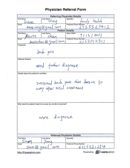
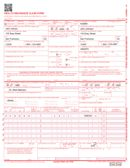
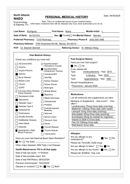
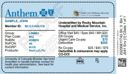

In [10]:
if analysis is not None:
    rows = []
    for d in analysis.documents:
        thumb = page_thumb_data_uri(combined_path, page_index=first_page_index(d.pages))
        rows.append({
            "Preview": f"<img src='{thumb}' style='width:110px; border:1px solid #ddd; border-radius:4px'>",
            "Document": d.document,
            "Pages": d.pages,
            "Page count": d.page_count,
            "Class": d.document_class,
        })
    table = pd.DataFrame(rows, columns=["Preview", "Document", "Pages", "Page count", "Class"])
    display(style_table(table, col_widths={0: "130px"}))
else:
    print("No structured result available, re-run Section 6.")

---
## 8. Extracted handwritten information

The markdown the model extracted from the document it identified as the physician referral form.

In [11]:
import re
from io import StringIO
import markdown as md_lib


def referral_to_frames(referral_md):
    """Return [(section_title, DataFrame), ...] from the model's referral markdown.
       Handles BOTH markdown tables and '- **Field:** value' bullet lists, so the
       extraction renders consistently regardless of which format the model returns."""
    parts = re.split(r"^\s*#{1,6}\s*(.+?)\s*$", referral_md, flags=re.M)
    sections = []
    if len(parts) == 1:
        sections.append((None, parts[0]))
    else:
        if parts[0].strip():
            sections.append((None, parts[0]))
        for i in range(1, len(parts), 2):
            sections.append((parts[i].strip(), parts[i + 1] if i + 1 < len(parts) else ""))

    frames = []
    for title, body in sections:
        # 1) markdown table in this section?
        if "|" in body and re.search(r"\|\s*:?-{2,}", body):
            try:
                html = md_lib.markdown(body, extensions=["tables"])
                for tbl in pd.read_html(StringIO(html)):
                    frames.append((title, tbl))
                continue
            except ValueError:
                pass
        # 2) else parse '- **Field:** value' bullet lines
        rows = []
        for line in body.splitlines():
            m = re.match(r"\s*[-*]\s*(.+?)\s*:\s*(.+?)\s*$", line)
            if m:
                field = m.group(1).strip().strip("*").strip()
                value = m.group(2).strip().strip("*").strip()
                if field:
                    rows.append({"Field": field, "Value": value})
        if rows:
            frames.append((title, pd.DataFrame(rows, columns=["Field", "Value"])))
    return frames


if analysis is not None:
    print(f"Auto-identified referral document: {analysis.referral_document}\n")
    frames = referral_to_frames(analysis.referral_markdown)
    if not frames:
        # Couldn't parse a clear structure; show the raw markdown so nothing is lost.
        display(Markdown(analysis.referral_markdown))
    else:
        for title, frame in frames:
            if title:
                display(HTML(f"<h3 style='margin:16px 0 6px; font-size:15px'>{title}</h3>"))
            display(style_table(frame, table_width="640px", col_widths={0: "40%"}))
else:
    print("No structured result available, re-run Section 6.")

Auto-identified referral document: Physician referral form



Field,Value
First Name,Irene
Last Name,Wong
Specialty,family health
Email,irenewong@gmail.com
Preferred Phone Number,6753369412


Field,Value
First Name,kevin (Kevin)
Last Name,chen (Chen)
Date of Birth,9/15/2001
Email,kevinchen@gmail.com
Preferred Phone Number,6153012311


Field,Value
Diagnosis,back pain
Referral Reason,need further diagnose
Details about the patient's condition,sustained back pain that doesn't go away after initial treatment
Why does the patient need to be seen by another physician?,more diagnose


Field,Value
First Name,Sam (written as Sam/Samy)
Last Name,Yong
Email,sam@gmail.com
Preferred Phone Number,6516331234


---
## 9. Download & render the bbox artifact

Retrieve the annotated image artifact with `client.artifacts.get(session_id, object_id)` from the **same** completion session and display it inline.

Saved artifact → referral_bbox_annotated.png



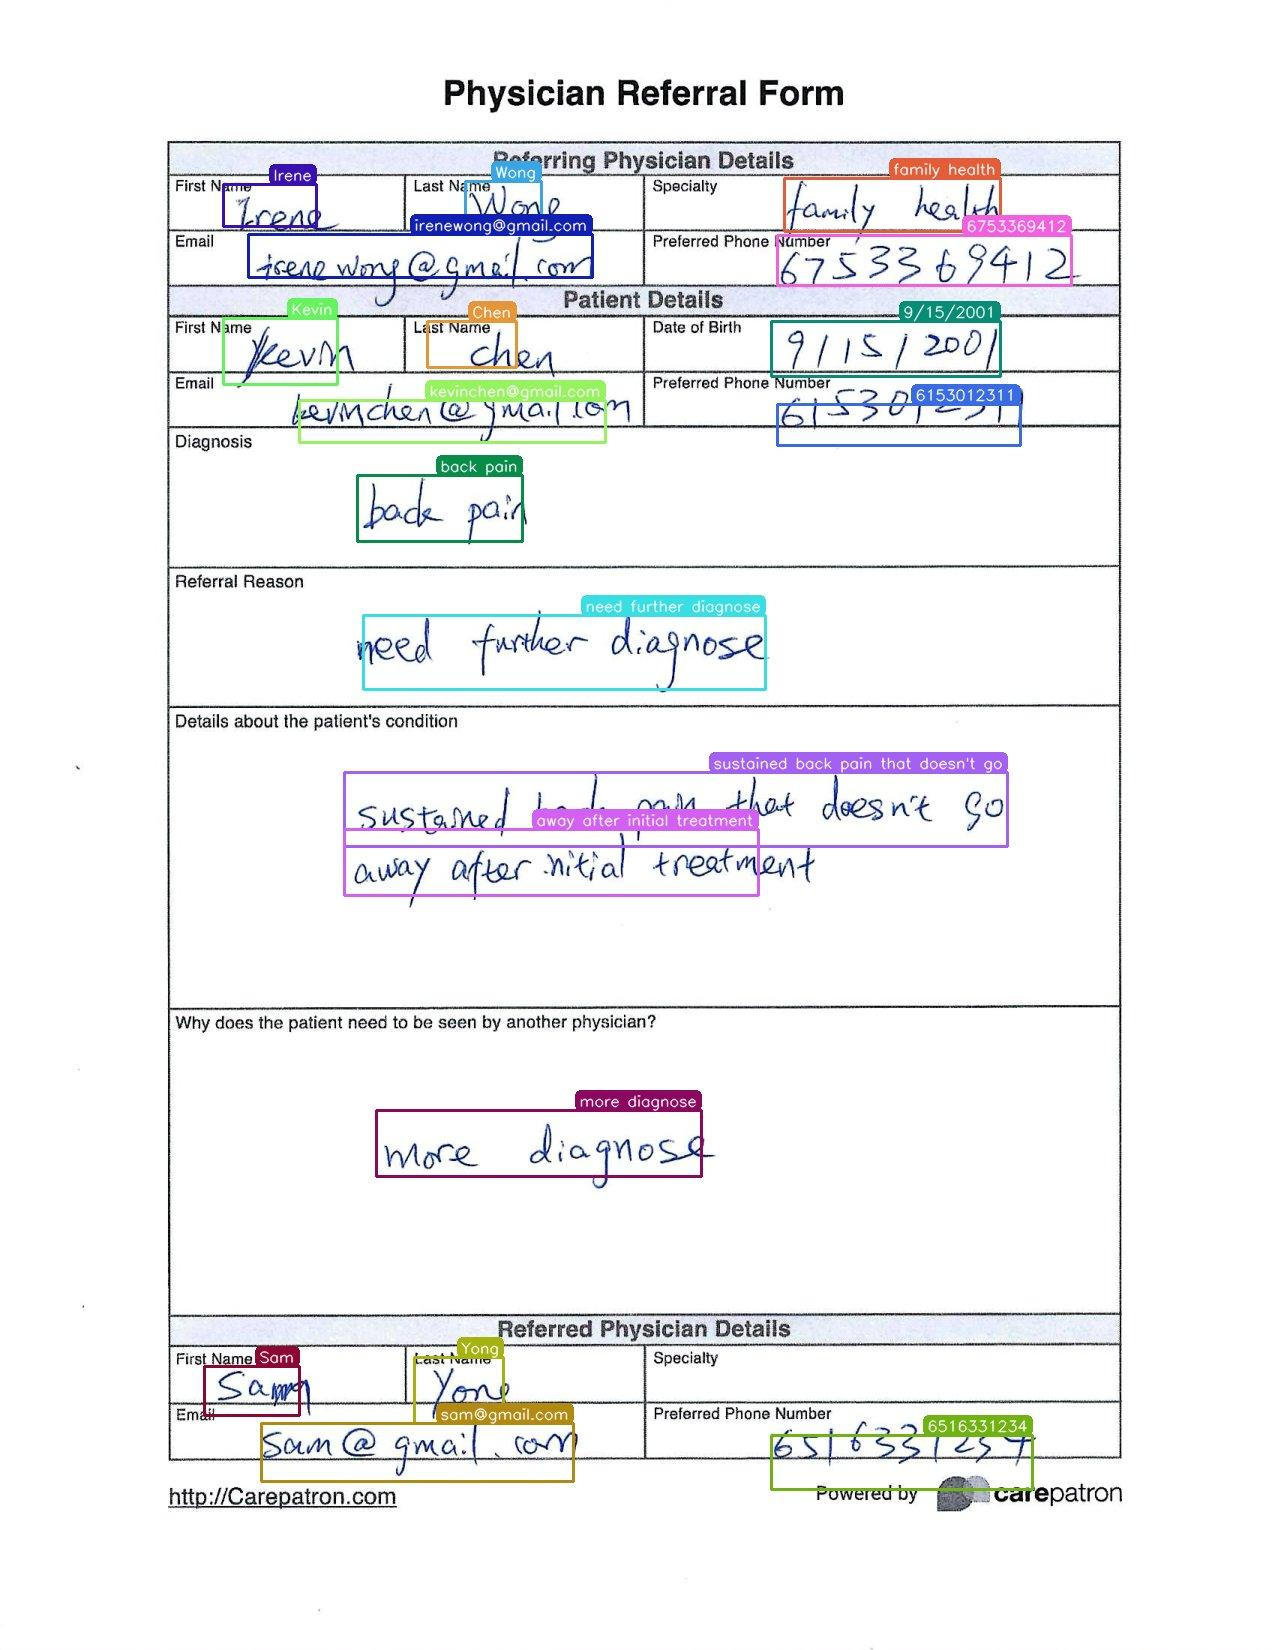

In [12]:
if analysis is not None:
    try:
        annotated_image = client.artifacts.get(
            session_id=session_id,
            object_id=analysis.annotated_image.id,
        )

        # Save a local copy alongside the notebook
        out_path = Path("referral_bbox_annotated.png")
        annotated_image.convert("RGB").save(out_path)
        print(f"Saved artifact → {out_path}")

        show_image(
            annotated_image,
            caption="Handwritten field detections on the auto-identified physician referral form",
            width=700,
        )
    except Exception as e:
        print(
            "Could not retrieve the bbox artifact "
            f"(id={analysis.annotated_image.id}): {type(e).__name__}: {e}\n"
            "The session may have expired or the agent may not have produced an "
            "annotated image on this run. Re-run Section 6 to regenerate it."
        )
else:
    print("No structured result available, re-run Section 6 to obtain the artifact reference.")